# Project 5B: Flow Matching from Scratch!

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import torch

def save_checkpoint(model, optimizer, epoch, path):
    checkpoint = {
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict()
    }
    torch.save(checkpoint, path)
    print(f"✅ Saved checkpoint at epoch {epoch} → {path}")


In [3]:
def load_checkpoint(model, optimizer, path, device="cuda"):
    if os.path.exists(path):
        checkpoint = torch.load(path, map_location=device)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"🔁 Resuming from epoch {start_epoch}")
        return start_epoch
    else:
        print("⚠ No checkpoint found, starting from epoch 0")
        return 0


## Setup environment

In [4]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.1 MB/s eta 0:00:00


In [5]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
import mediapy as media
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm
import numpy as np
import torch.optim as optimizers
from torchvision import datasets, transforms

## Neural Network Resources

In this part, you will build and train a [UNet](https://arxiv.org/abs/1505.04597), which is more complex than the MLP you implemented in the NeRF project.  We provide all class definitions you may need (but feel free to add or modify them as necessary).  

Instead of asking ChatGPT to write everything for you, please consult the following resources when you get stuck — they will help you understand how and why things work under the hood.

- PyTorch Documentation — [`Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), and [`AvgPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html).
- PyTorch Documentation - [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html), the dataset we gonna use, and [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html), the off-the-shell dataloader we can directly use.
- PyTorch [tutorial](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) on how to train a classifier on CIFAR10 dataset. The structure of your training code will be very similar to this one.

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [6]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.layers(x)
        return x
        # ===== end of code ====


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 4, 2, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.layers(x)
        return x
        # ===== end of code ====


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.layers = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels,
                               kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.layers(x)
        return x
        # ===== end of code ====


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        # ===== your code here! ====
        self.pool = nn.AvgPool2d(7)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.pool(x)
        return x
        # ===== end of code ====


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.up = nn.ConvTranspose2d(in_channels, in_channels, 7)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.up(x)
        return x
        # ===== end of code ====


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.layers = nn.Sequential(
            Conv(in_channels, out_channels),
            Conv(out_channels, out_channels)
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.layers(x)
        return x
        # ===== end of code ====


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.layers = nn.Sequential(
            DownConv(in_channels, out_channels),
            ConvBlock(out_channels, out_channels)
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.layers(x)
        return x
        # ===== end of code ====


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.layers = nn.Sequential(
            UpConv(in_channels, out_channels),
            ConvBlock(out_channels, out_channels)
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.layers(x)
        return x
        # ===== end of code ====

## Implementing Unconditional UNet

In [7]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        D: int,
    ):
        super().__init__()
        # ===== your code here! ====
        # ---------- Encoder ----------
        self.enc1 = ConvBlock(in_channels, D)      # D, 28, 28
        self.down1 = DownBlock(D, D)               # D, 14, 14

        self.enc2 = ConvBlock(D, D)                # D, 14, 14
        self.down2 = DownBlock(D, 2*D)             # 2D, 7, 7

        self.enc3 = ConvBlock(2*D, 2*D)            # 2D, 7, 7

        # ---------- Bottleneck ----------
        self.flatten = Flatten()                   # 2D,1,1
        self.unflatten = Unflatten(2*D)            # 2D,7,7

        # ---------- Decoder ----------
        # UpBlock after 4D concat
        self.up1 = UpBlock(4*D, D)               # 7→14

        # UpBlock after 2D concat
        self.up2 = UpBlock(2*D, D)                 # 14→28

        # Final block at 28×28 concat
        self.final_convblock = ConvBlock(2*D, D)   # 28×28
        self.final = nn.Conv2d(D, 1, 1)            # output
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        # ----- Encoder -----
        e1 = self.enc1(x)       # [D,28,28]
        d1 = self.down1(e1)     # [D,14,14]

        e2 = self.enc2(d1)      # [D,14,14]
        d2 = self.down2(e2)     # [2D,7,7]

        e3 = self.enc3(d2)      # [2D,7,7]

        # ----- Bottleneck -----
        b = self.flatten(e3)    # [2D,1,1]
        b = self.unflatten(b)   # [2D,7,7]

        # ----- Decoder -----
        # concat level 1 (7×7)
        u1_in = torch.cat([b, e3], dim=1)   # [4D,7,7]
        u1 = self.up1(u1_in)                # [D,14,14]

        # concat level 2 (14×14)
        u2_in = torch.cat([u1, e2], dim=1)  # [2D,14,14]
        u2 = self.up2(u2_in)                # [D,28,28]

        # concat level 3 (28×28)
        u3_in = torch.cat([u2, e1], dim=1)  # [2D,28,28]
        u3 = self.final_convblock(u3_in)    # [D,28,28]

        out = self.final(u3)                # [1,28,28]
        return out
        # ===== end of code ====

# Part 1.2: Using the UNet to Train a Denoiser

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 521kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.79MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.4MB/s]


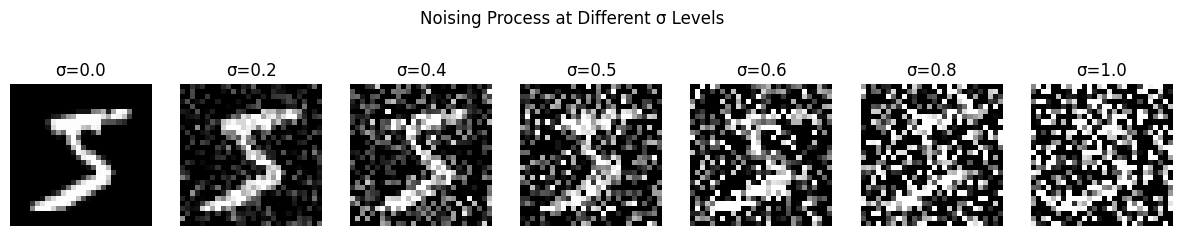

In [8]:
# Visualize images at different noisy level
# ===== your code here! ====

# ---------- 1. Load MNIST ----------
transform = transforms.Compose([
    transforms.ToTensor(),        # converts to [0,1]
])

mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Take one sample image (shape: [1,28,28])
x, _ = mnist[0]
x = x.unsqueeze(0)                # [1,1,28,28] for consistency

# ---------- 2. Define different noise levels ----------
sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]


# ---------- 3. Add noise and visualize ----------
fig, axs = plt.subplots(1, len(sigmas), figsize=(15, 3))

for i, sigma in enumerate(sigmas):
    eps = torch.randn_like(x)
    z = x + sigma * eps
    z = z.clamp(0, 1)             # keep within valid range

    axs[i].imshow(z.squeeze().cpu(), cmap='gray')
    axs[i].set_title(f"σ={sigma}")
    axs[i].axis('off')

plt.suptitle("Noising Process at Different σ Levels")
plt.show()
# ===== end of code ====

## Part 1.2.1: Training

For this part, we provide some structure code for training. It is very basic, so feel free to change them or add your code. In later section we won't provide any training or visualization structure code.

In [9]:
device = torch.device('cuda')

# Set your hyperparameters
# ===== your code here! ====
batch_size = 256
learning_rate = 1e-4
noise_level = 0.5
hidden_dim = 128
num_epochs = 5
# ===== end of code ====

In [10]:
# Define your datasets and dataloaders
# ===== your code here! ====
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# ===== end of code ====

In [11]:
# Define your model, optimizer, and loss
# ===== your code here! ====

model = UnconditionalUNet(1, hidden_dim).to(device)
optimizer = optimizers.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
# ===== end of code ====

100%|██████████| 235/235 [01:39<00:00,  2.35it/s]



=== Visualization after epoch 1 ===


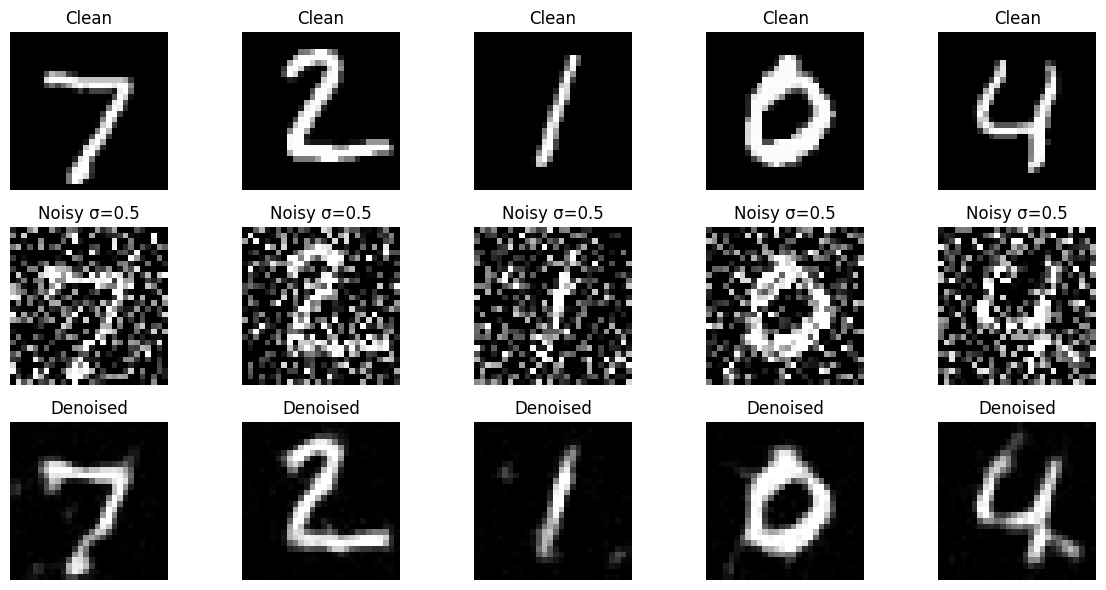

100%|██████████| 235/235 [01:41<00:00,  2.31it/s]



=== Visualization after epoch 5 ===


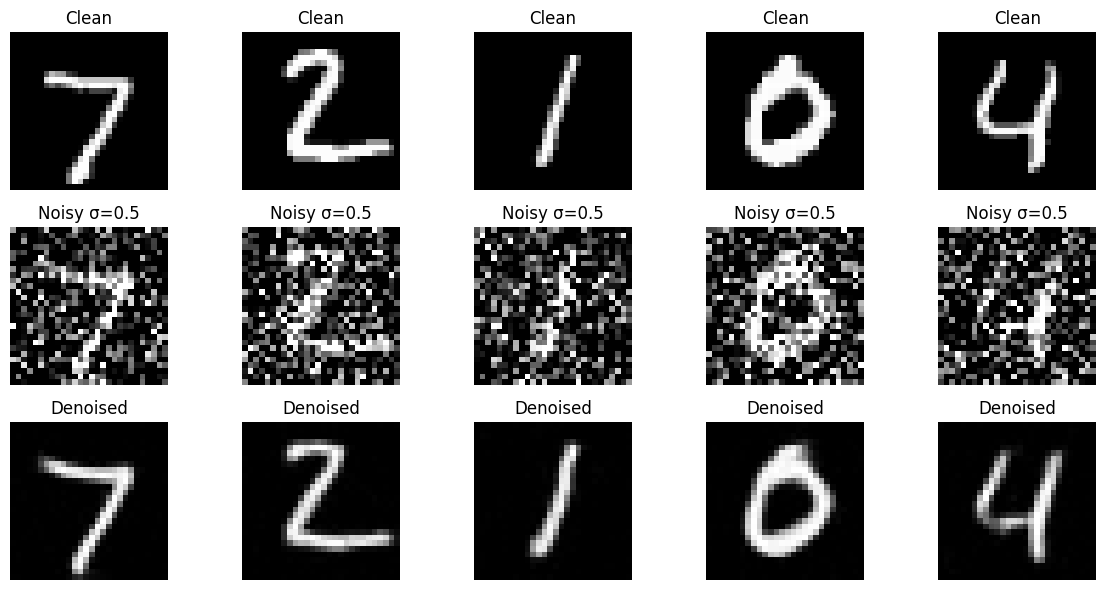

In [12]:
def visualize_denoising(model, test_loader, sigma=0.5, device="cuda"):
    model.eval()
    images, _ = next(iter(test_loader))   # take one batch
    images = images[:5].to(device)        # take first 5

    # create noisy images
    eps = torch.randn_like(images)
    noisy = (images + sigma * eps).clamp(0,1)

    with torch.no_grad():
        denoised = model(noisy).clamp(0,1)

    plt.figure(figsize=(12,6))

    for i in range(5):
        # clean
        plt.subplot(3,5,i+1)
        plt.imshow(images[i].squeeze().cpu(), cmap='gray')
        plt.title("Clean")
        plt.axis("off")

        # noisy
        plt.subplot(3,5,i+6)
        plt.imshow(noisy[i].squeeze().cpu(), cmap='gray')
        plt.title(f"Noisy σ={sigma}")
        plt.axis("off")

        # output
        plt.subplot(3,5,i+11)
        plt.imshow(denoised[i].squeeze().cpu(), cmap='gray')
        plt.title("Denoised")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# The training loops
train_losses = []
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(tqdm(train_loader)):

        # ===== your code here! ====
        images = images.to(device)
        eps = torch.randn_like(images)
        z = images + noise_level * eps
        z = z.clamp(0, 1)

        outputs = model(z)

        # ===== end of code ====

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
    if epoch == 0 or epoch == 4:
        print(f"\n=== Visualization after epoch {epoch+1} ===")
        visualize_denoising(model, test_loader, sigma=0.5, device=device)

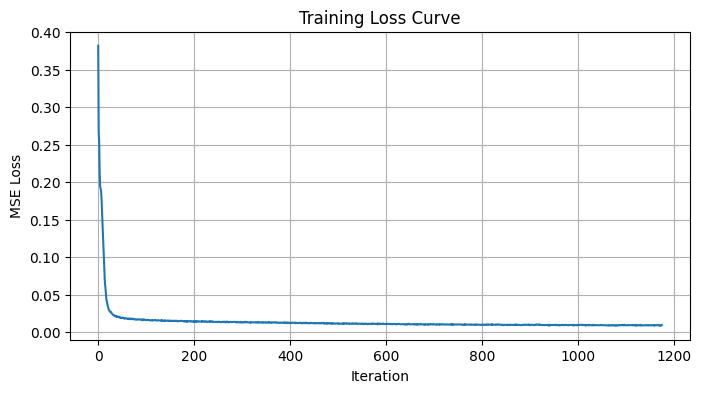

In [13]:
# Visualize your training curve
# ===== your code here! ====
plt.figure(figsize=(8,4))
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()
# ===== end of code ====

## Part 1.2.2: Out-of-Distribution Testing

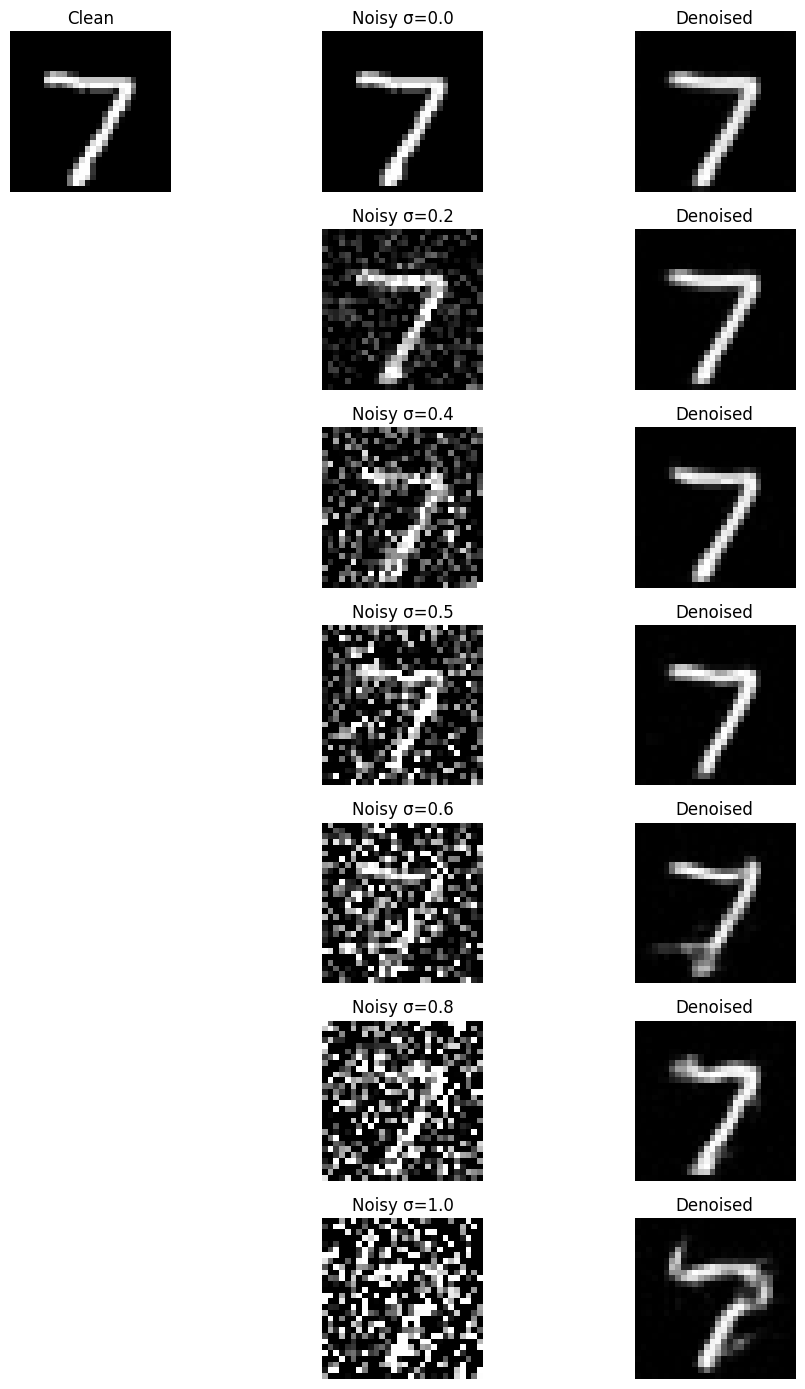

In [14]:
# Visualize OOD testing
# ===== your code here! ====
def visualize_ood_noise(model, test_loader, device="cuda"):
    model.eval()

    # Take one test image
    images, _ = next(iter(test_loader))
    x = images[0:1].to(device)   # shape [1,1,28,28]

    # Noise levels to test
    sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

    plt.figure(figsize=(10, 2 * len(sigmas)))

    for idx, sigma in enumerate(sigmas):
        eps = torch.randn_like(x)
        noisy = (x + sigma * eps).clamp(0, 1)

        with torch.no_grad():
            denoised = model(noisy).clamp(0, 1)

        # Clean image only once
        if idx == 0:
            plt.subplot(len(sigmas), 3, 1)
            plt.imshow(x.squeeze().cpu(), cmap='gray')
            plt.title("Clean")
            plt.axis('off')

        # Noisy image
        plt.subplot(len(sigmas), 3, idx*3 + 2)
        plt.imshow(noisy.squeeze().cpu(), cmap='gray')
        plt.title(f"Noisy σ={sigma}")
        plt.axis('off')

        # Denoised output
        plt.subplot(len(sigmas), 3, idx*3 + 3)
        plt.imshow(denoised.squeeze().cpu(), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_ood_noise(model, test_loader, device=device)
# ===== end of code ====


## Part 1.2.3 Denoising Pure Noise

In [15]:
checkpoint_path = "/content/drive/MyDrive/mnist_denoiser_checkpoint.pt"

start_epoch = load_checkpoint(model, optimizer, checkpoint_path, device)

🔁 Resuming from epoch 5


100%|██████████| 235/235 [01:44<00:00,  2.25it/s]


✅ Saved checkpoint at epoch 0 → /content/drive/MyDrive/mnist_denoiser_checkpoint.pt

=== Visualization after epoch 1 ===


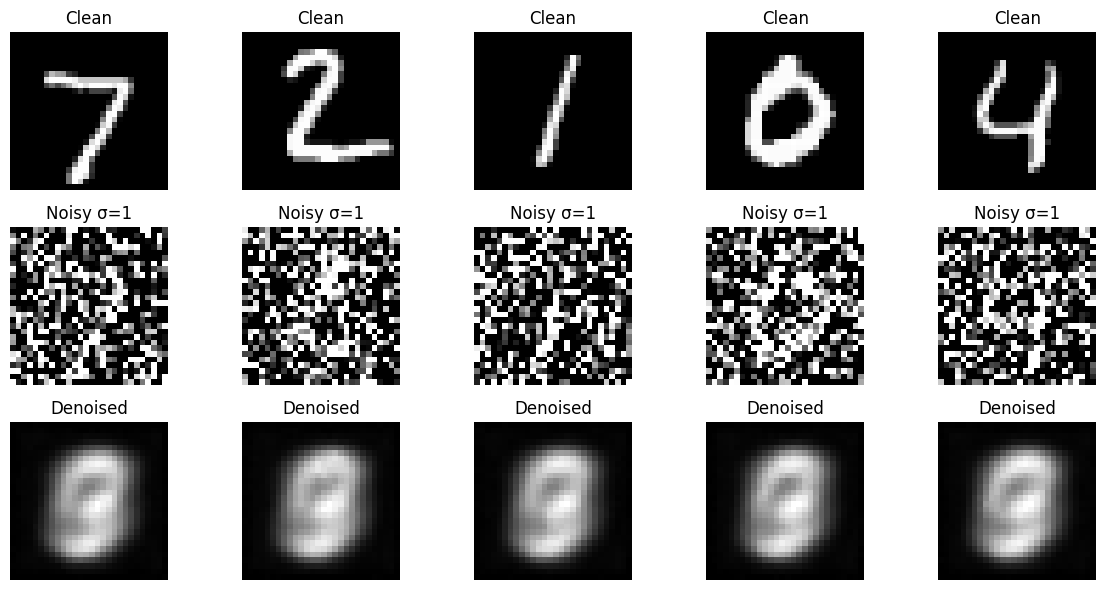

100%|██████████| 235/235 [01:44<00:00,  2.24it/s]


✅ Saved checkpoint at epoch 1 → /content/drive/MyDrive/mnist_denoiser_checkpoint.pt


100%|██████████| 235/235 [01:43<00:00,  2.27it/s]


✅ Saved checkpoint at epoch 2 → /content/drive/MyDrive/mnist_denoiser_checkpoint.pt


100%|██████████| 235/235 [01:45<00:00,  2.24it/s]


✅ Saved checkpoint at epoch 3 → /content/drive/MyDrive/mnist_denoiser_checkpoint.pt


100%|██████████| 235/235 [01:45<00:00,  2.23it/s]


✅ Saved checkpoint at epoch 4 → /content/drive/MyDrive/mnist_denoiser_checkpoint.pt

=== Visualization after epoch 5 ===


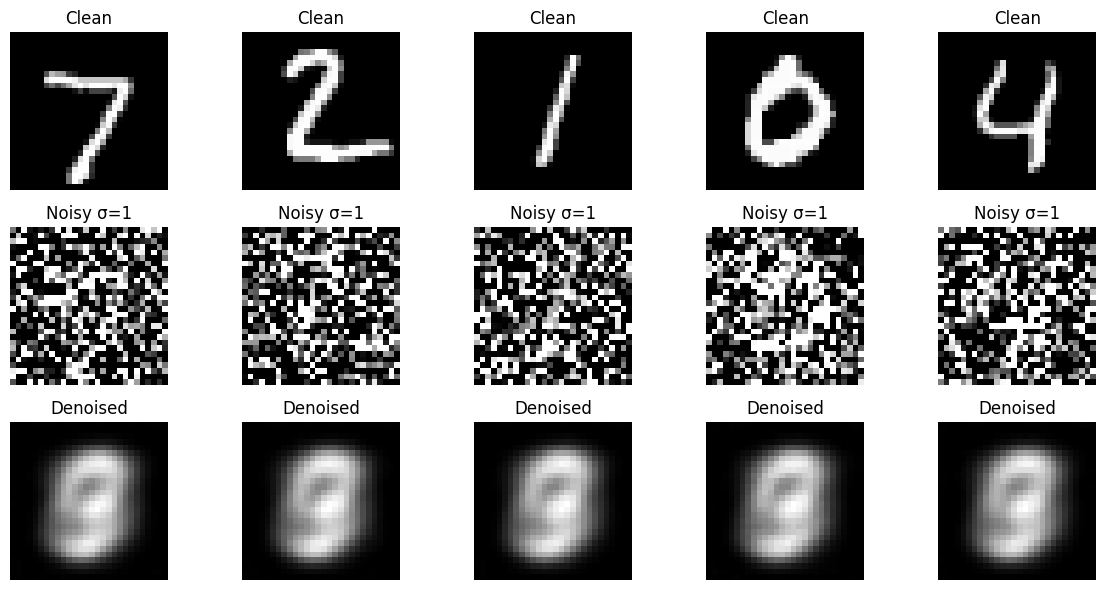

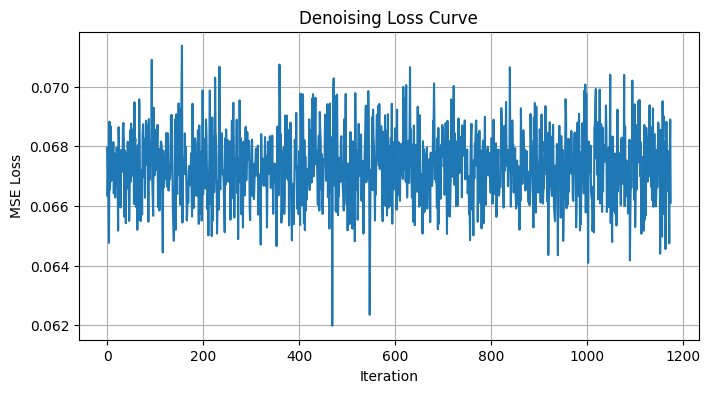

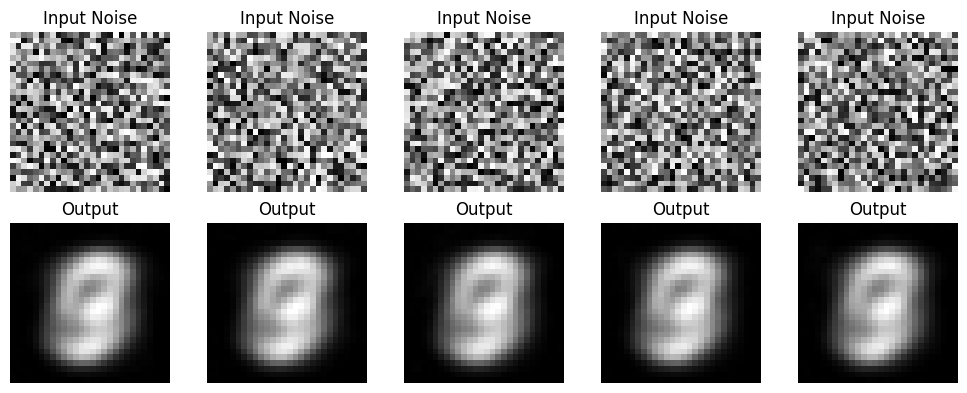

In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
denoise_losses = []
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(tqdm(train_loader)):

        # ===== your code here! ====
        images = images.to(device)
        eps = torch.randn_like(images)
        z = eps
        z = z.clamp(0, 1)

        outputs = model(z)

        # ===== end of code ====

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        denoise_losses.append(loss.item())

    # ===== 保存 checkpoint =====
    save_checkpoint(model, optimizer, epoch, checkpoint_path)

    if epoch == 0 or epoch == 4:
        print(f"\n=== Visualization after epoch {epoch+1} ===")
        visualize_denoising(model, test_loader, sigma=1, device=device)

plt.figure(figsize=(8,4))
plt.plot(denoise_losses)
plt.title("Denoising Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

def sample_from_pure_noise(model, num=5, device="cuda"):
    model.eval()
    with torch.no_grad():
        # pure Gaussian noise in [0,1]
        z = torch.rand((num, 1, 28, 28), device=device)  # uniform 0~1
        # you can also use torch.randn and clamp
        # z = torch.randn((num,1,28,28), device=device).clamp(0,1)

        outputs = model(z).clamp(0, 1)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))

    for i in range(num):
        plt.subplot(2, num, i+1)
        plt.imshow(z[i].squeeze().cpu(), cmap='gray')
        plt.title("Input Noise")
        plt.axis("off")

        plt.subplot(2, num, i+num+1)
        plt.imshow(outputs[i].squeeze().cpu(), cmap='gray')
        plt.title("Output")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

sample_from_pure_noise(model, num=5, device=device)

# ===== end of code ====

# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [16]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.layers = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, out_channels)
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        out = self.layers(x)            # (N, out_channels)
        return out.unsqueeze(-1).unsqueeze(-1)   # (N, out_channels, 1, 1)
        # ===== end of code ====


class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        D: int,
    ):
        super().__init__()
        # ===== your code here! ====
        self.enc1 = ConvBlock(in_channels, D)      # D, 28, 28
        self.down1 = DownBlock(D, D)               # D, 14, 14

        self.enc2 = ConvBlock(D, D)                # D, 14, 14
        self.down2 = DownBlock(D, 2*D)             # 2D, 7, 7

        self.enc3 = ConvBlock(2*D, 2*D)            # 2D, 7, 7

        # ---------- Bottleneck ----------
        self.flatten = Flatten()                   # 2D,1,1
        self.unflatten = Unflatten(2*D)            # 2D,7,7

        # ---------- Decoder ----------
        # UpBlock after 4D concat
        self.up1 = UpBlock(4*D, D)               # 7→14

        # UpBlock after 2D concat
        self.up2 = UpBlock(2*D, D)                 # 14→28

        # Final block at 28×28 concat
        self.final_convblock = ConvBlock(2*D, D)   # 28×28
        self.final = nn.Conv2d(D, 1, 1)            # output

        self.FCBlock1 = FCBlock(1,2*D)
        self.FCBlock2 = FCBlock(1,D)
        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        # === Encoder ===
        e1 = self.enc1(x)          # (N,D,28,28)
        d1 = self.down1(e1)        # (N,D,14,14)

        e2 = self.enc2(d1)         # (N,D,14,14)
        d2 = self.down2(e2)        # (N,2D,7,7)

        e3 = self.enc3(d2)         # (N,2D,7,7)

        # === Bottleneck ===
        b = self.flatten(e3)       # (N,2D,1,1)
        b = self.unflatten(b)      # (N,2D,7,7)

        t_in = t.unsqueeze(1).float()   # (N,1)
        t1 = self.FCBlock1(t_in)        # (N,2D,1,1)
        t2 = self.FCBlock2(t_in)        # (N,D,1,1)

        b = b * t1                      # 广播到 (N,2D,7,7)

        # === Decoder ===
        u1_in = torch.cat([b, e3], dim=1)   # (N,4D,7,7)
        u1 = self.up1(u1_in)               # (N,D,14,14)

        u1 = u1 * t2                       # (N,D,14,14)

        u2_in = torch.cat([u1, e2], dim=1) # (N,2D,14,14)
        u2 = self.up2(u2_in)               # (N,D,28,28)

        u3_in = torch.cat([u2, e1], dim=1) # (N,2D,28,28)
        u3 = self.final_convblock(u3_in)   # (N,D,28,28)

        out = self.final(u3)               # (N,1,28,28)
        return out
        # ===== end of code ====

## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [17]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    criterion = nn.MSELoss()
    x_1 = x_1.to(device)
    x_0 = torch.randn_like(x_1)
    t = torch.rand(x_1.size(0), 1, 1, 1, device=x_1.device)
    z = t * x_1 + (1-t) * x_0
    outputs = unet(z, t.squeeze())
    loss = criterion(outputs, x_1 - x_0)
    return loss
    # ===== end of code ====

In [18]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    device = next(unet.parameters()).device
    unet.eval()
    torch.manual_seed(seed)

    H, W = img_wh
    x_t = torch.randn(1, 1, H, W, device=device)

    dt = 1.0 / num_ts

    for i in range(num_ts):
        # t shape must match batch size
        t = torch.full((x_t.size(0),), i * dt, device=device)  # (1,)
        v_hat = unet(x_t, t)    # (1,1,H,W)
        x_t = x_t + v_hat * dt

    return x_t
    # ===== end of code ====

In [19]:
class TimeConditionalFM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()

        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return time_fm_forward(
            self.unet, x, self.num_ts
        )


    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return time_fm_sample(
            self.unet, img_wh, self.num_ts, seed
        )


# Part 2.2: Training the Time-conditioned UNet

100%|██████████| 235/235 [00:42<00:00,  5.49it/s]


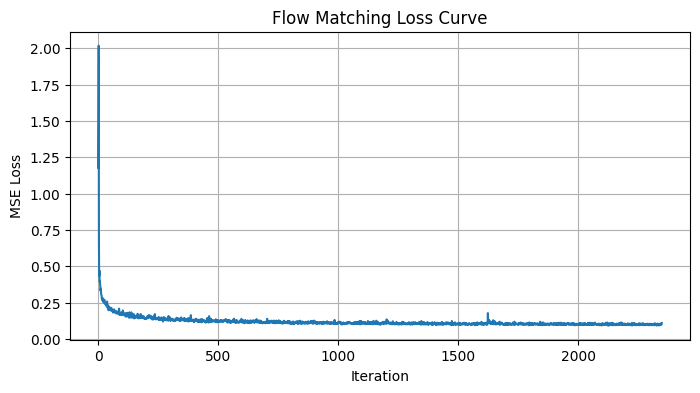

In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====

num_epochs = 10
model = TimeConditionalUNet(in_channels=1, num_classes=10, D=64).to(device)
model = TimeConditionalFM(model)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
criterion = nn.MSELoss()
gamma = 0.1 ** (1.0 / num_epochs)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
flow_losses = []
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(tqdm(train_loader)):
        images = images.to(device)

        loss = model(images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        flow_losses.append(loss.item())
    scheduler.step()
    if epoch+1 in [1, 5, 10]:
        torch.save(model.state_dict(), f"unet_epoch_{epoch+1}.pth")

plt.figure(figsize=(8,4))
plt.plot(flow_losses)
plt.title("Flow Matching Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()
# ===== end of code ====

# Part 2.3: Sampling from the Time-conditioned UNet

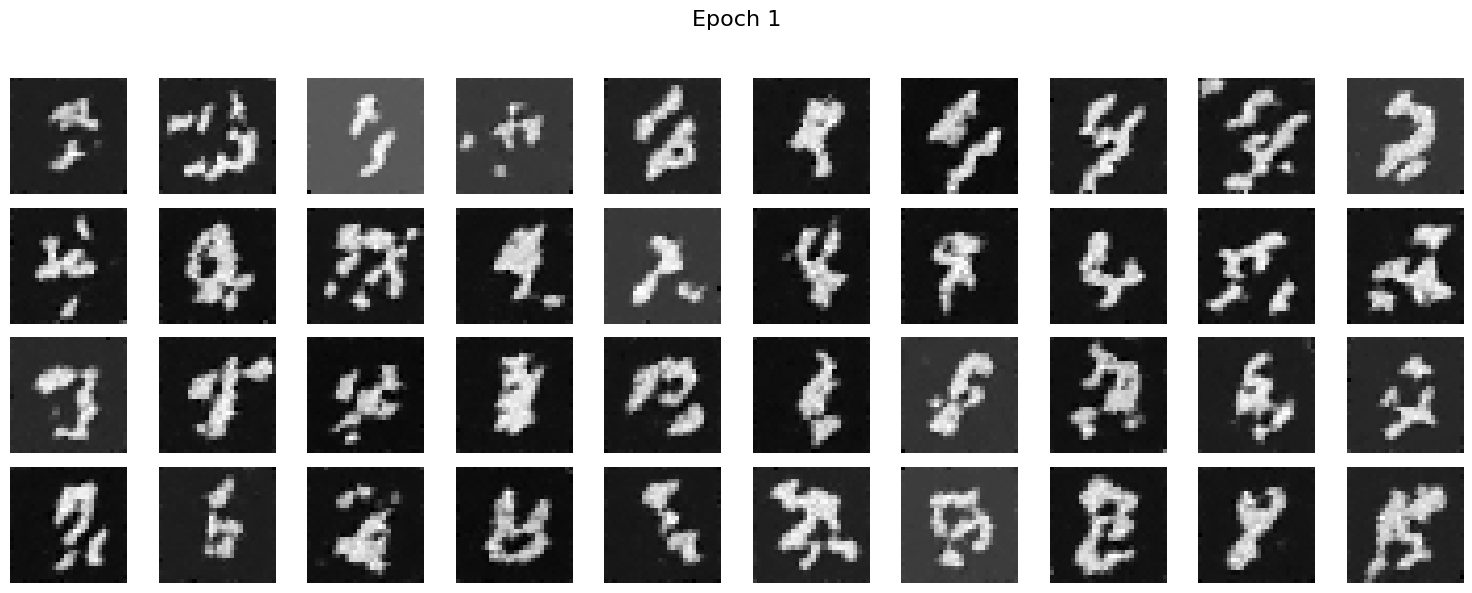

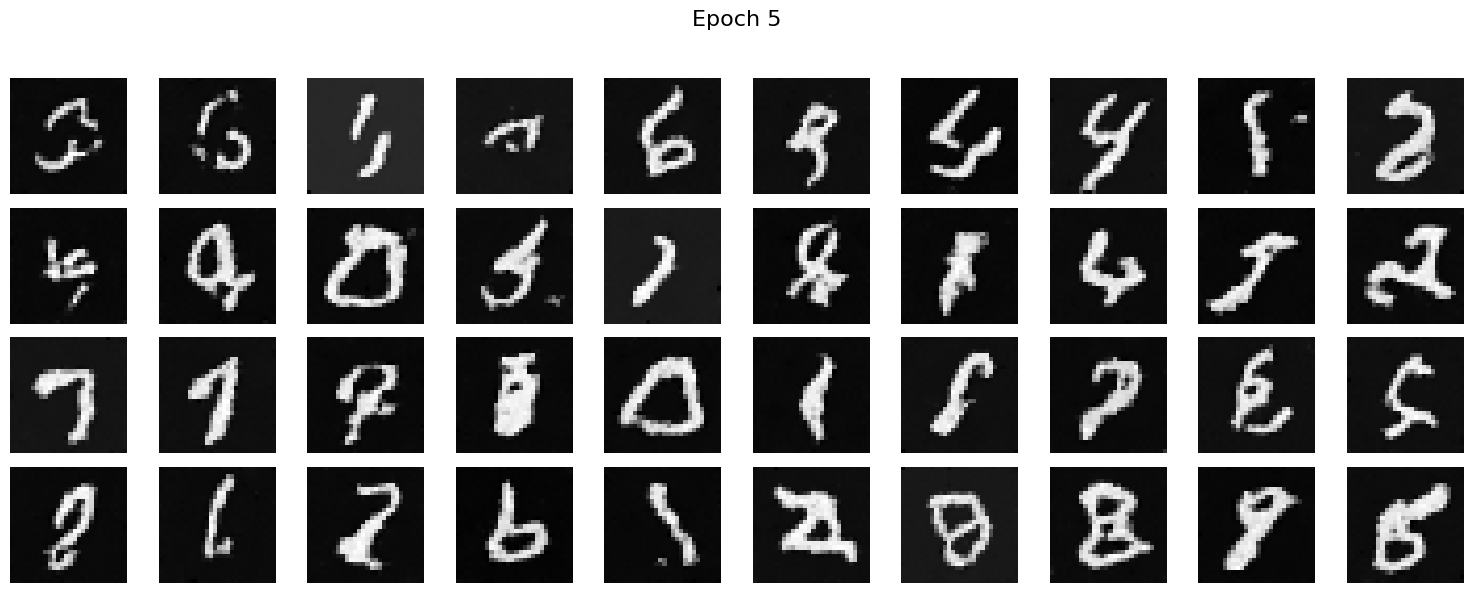

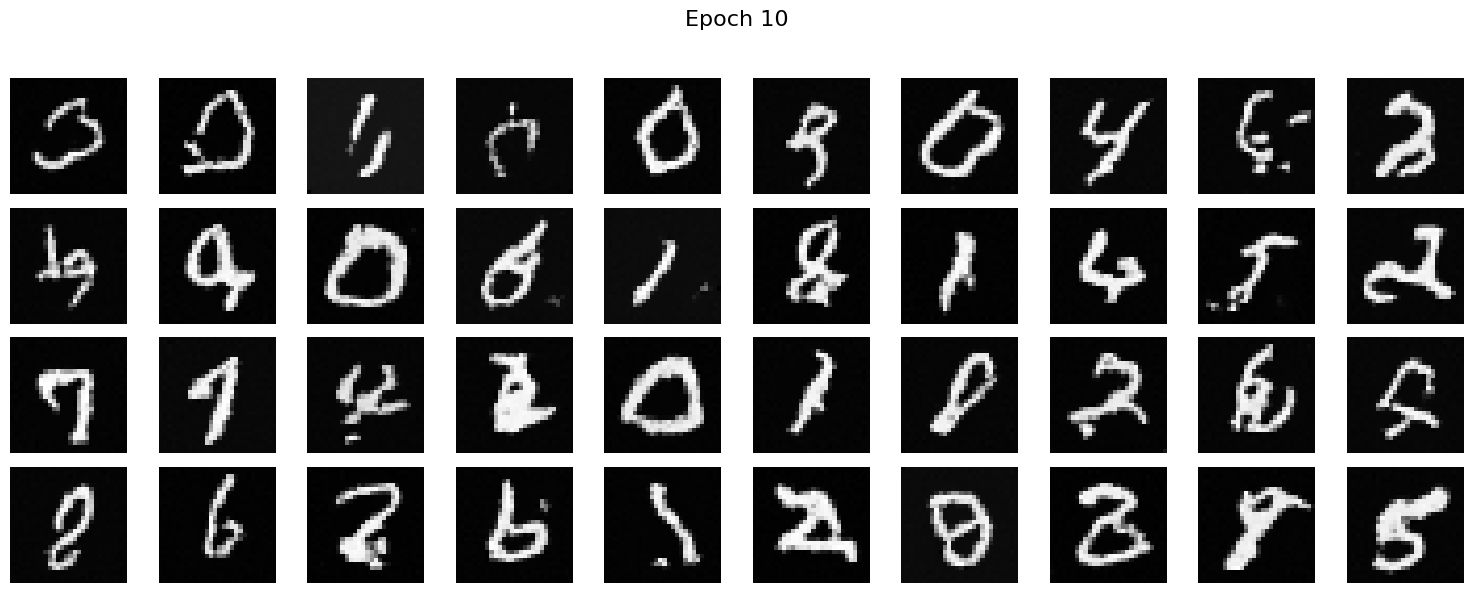

In [ ]:
# Sampling from the UNet
# ===== your code here! ====

num_rows = 4
num_cols = 10
num_samples = num_rows * num_cols

checkpoints = {
    "Epoch 1":  "unet_epoch_1.pth",
    "Epoch 5":  "unet_epoch_5.pth",
    "Epoch 10": "unet_epoch_10.pth",
}

for title, ckpt_path in checkpoints.items():
    model = TimeConditionalUNet(in_channels=1, num_classes=10, D=64).to(device)
    model = TimeConditionalFM(model)
    model.load_state_dict(torch.load(ckpt_path))
    model.eval()

    fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*1.5, num_rows*1.5))
    fig.suptitle(title, fontsize=16)

    for i in range(num_rows):
        for j in range(num_cols):
            idx = i * num_cols + j
            sample = model.sample((28, 28), seed=idx)

            axs[i, j].imshow(sample[0,0].cpu(), cmap="gray")
            axs[i, j].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ===== end of code ====


# Part 2.4: Implementing a Class-conditioned UNet

In [20]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens

        # === Encoder ===
        self.enc1 = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)

        self.enc2 = ConvBlock(D, D)
        self.down2 = DownBlock(D, 2*D)

        self.enc3 = ConvBlock(2*D, 2*D)

        # === Bottleneck ===
        self.flatten = Flatten()
        self.unflatten = Unflatten(2*D)

        # === Decoder ===
        self.up1 = UpBlock(4*D, D)
        self.up2 = UpBlock(2*D, D)

        self.final_convblock = ConvBlock(2*D, D)
        self.final = nn.Conv2d(D, 1, 1)

        # === Four Modulation FCBlocks ===
        self.fc1_t = FCBlock(1, 2*D)
        self.fc1_c = FCBlock(num_classes, 2*D)

        self.fc2_t = FCBlock(1, D)
        self.fc2_c = FCBlock(num_classes, D)

        # embed class id (N,) → (N,1)
        self.class_embed = nn.Embedding(num_classes, 1)
        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        # apply mask if needed
        N = x.size(0)

        # ----- prepare t -----
        t_in = t.view(N, 1).float()     # (N,1)

        # ----- prepare one-hot c -----
        c_onehot = torch.zeros(N, 10, device=x.device)
        c_onehot[torch.arange(N), c.long()] = 1.0

        if mask is not None:
            # mask = 0 → set class one-hot to all zeros
            c_onehot = c_onehot * mask.view(N,1)

        # ===== Encoder =====
        e1 = self.enc1(x)
        d1 = self.down1(e1)
        e2 = self.enc2(d1)
        d2 = self.down2(e2)
        e3 = self.enc3(d2)

        # ===== Bottleneck =====
        b = self.flatten(e3)
        b = self.unflatten(b)

        # ===== Modulate unflatten =====
        t1 = self.fc1_t(t_in)           # (N,2D,1,1)
        c1 = self.fc1_c(c_onehot)       # (N,2D,1,1)
        b = c1 * b + t1                 # (N,2D,7,7)

        # ===== Decoder =====
        u1_in = torch.cat([b, e3], dim=1)
        u1 = self.up1(u1_in)

        # ===== Modulate up1 =====
        t2 = self.fc2_t(t_in)           # (N,D,1,1)
        c2 = self.fc2_c(c_onehot)       # (N,D,1,1)
        u1 = c2 * u1 + t2

        # ===== Continue decoder =====
        u2_in = torch.cat([u1, e2], dim=1)
        u2 = self.up2(u2_in)

        u3_in = torch.cat([u2, e1], dim=1)
        u3 = self.final_convblock(u3_in)

        out = self.final(u3)
        return out
        # ===== end of code ====

In [21]:
def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    x_1 = x_1.to(device)
    c = c.to(device)
    x_0 = torch.randn_like(x_1)
    t = torch.rand(x_1.size(0), device=x_1.device)
    x_t = t.view(-1,1,1,1) * x_1 + (1 - t).view(-1,1,1,1) * x_0
    mask = (torch.rand_like(t) > p_uncond).float()   # (N,)
    v = x_1 - x_0
    v_hat = unet(x_t, c, t, mask)
    loss = ((v_hat - v) ** 2).mean()
    return loss

    # ===== end of code ====

In [22]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # ===== your code here! ====
    device = next(unet.parameters()).device
    torch.manual_seed(seed)

    N = c.size(0)
    H, W = img_wh

    # 1. start from noise
    x_t = torch.randn(N, 1, H, W, device=device)

    dt = 1.0 / num_ts

    # cache for animations: (N, T, 1, H, W)
    caches = torch.zeros(N, num_ts, 1, H, W, device=device)

    for i in range(num_ts):
        t = torch.full((N,), i * dt, device=device)

        # 2. unconditional forward
        mask_uncond = torch.zeros_like(t, dtype=torch.long)
        v_uncond = unet(x_t, c, t, mask_uncond)

        # 3. conditional forward
        mask_cond   = torch.ones_like(t,  dtype=torch.long)
        v_cond = unet(x_t, c, t, mask_cond)

        # 4. classifier-free guidance
        v_hat = v_uncond + guidance_scale * (v_cond - v_uncond)

        # 5. Euler ODE step
        x_t = x_t + v_hat * dt

        caches[:, i] = x_t.clone()

    return x_t, caches
    # ===== end of code ====

In [23]:
class ClassConditionalFM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return class_fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return class_fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

# Part 2.5 Training the Class-conditioned UNet

Start training...


100%|██████████| 235/235 [00:42<00:00,  5.47it/s]


[Epoch 1/10]  loss = 0.144225
Saved checkpoint: cc_unet_epoch_1.pth


100%|██████████| 235/235 [00:42<00:00,  5.50it/s]


[Epoch 2/10]  loss = 0.113454


...

[Epoch 8/10]  loss = 0.098176


100%|██████████| 235/235 [00:42<00:00,  5.49it/s]


[Epoch 9/10]  loss = 0.094887


100%|██████████| 235/235 [00:42<00:00,  5.50it/s]

[Epoch 10/10]  loss = 0.097005
Saved checkpoint: cc_unet_epoch_10.pth
Training done.


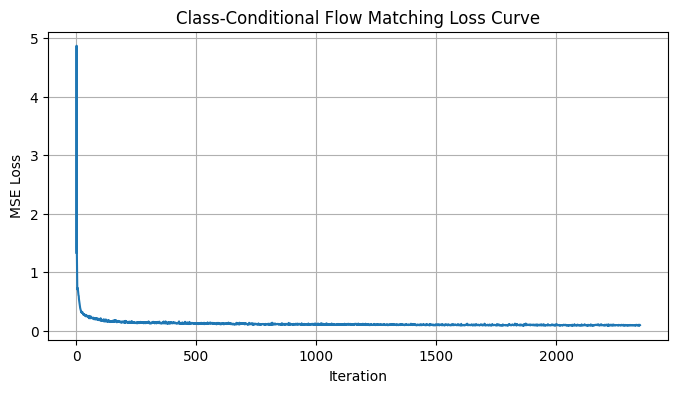

In [24]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
cc_unet = ClassConditionalUNet(
    in_channels=1,
    num_classes=10,
    num_hiddens=64,
).to(device)

model = ClassConditionalFM(
    unet=cc_unet,
    num_ts=300,
    p_uncond=0.1,
).to(device)
# ====== Training for Class-Conditional Flow Matching ======

num_epochs = 10
num_ts = 300     # already set inside model, here only for clarity
lr = 1e-2

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# exponential lr scheduler
gamma = 0.1 ** (1.0 / num_epochs)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

class_flow_losses = []

print("Start training...")

for epoch in range(num_epochs):
    model.train()

    for x, c in tqdm(train_loader):
        x = x.to(device)
        c = c.to(device)

        # Algorithm 3 loss
        loss = model(x, c)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        class_flow_losses.append(loss.item())

    scheduler.step()

    print(f"[Epoch {epoch+1}/{num_epochs}]  loss = {loss.item():.6f}")

    # ===== 保存 checkpoint at epoch 1, 5, 10 =====
    if (epoch + 1) in [1, 5, 10]:
        torch.save(model.unet.state_dict(), f"cc_unet_epoch_{epoch+1}.pth")
        print(f"Saved checkpoint: cc_unet_epoch_{epoch+1}.pth")

print("Training done.")

plt.figure(figsize=(8,4))
plt.plot(class_flow_losses)
plt.title("Class-Conditional Flow Matching Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


# ===== end of code ====

# Part 2.6: Sampling from the Class-conditioned UNet

Sampling for Epoch 1 ...


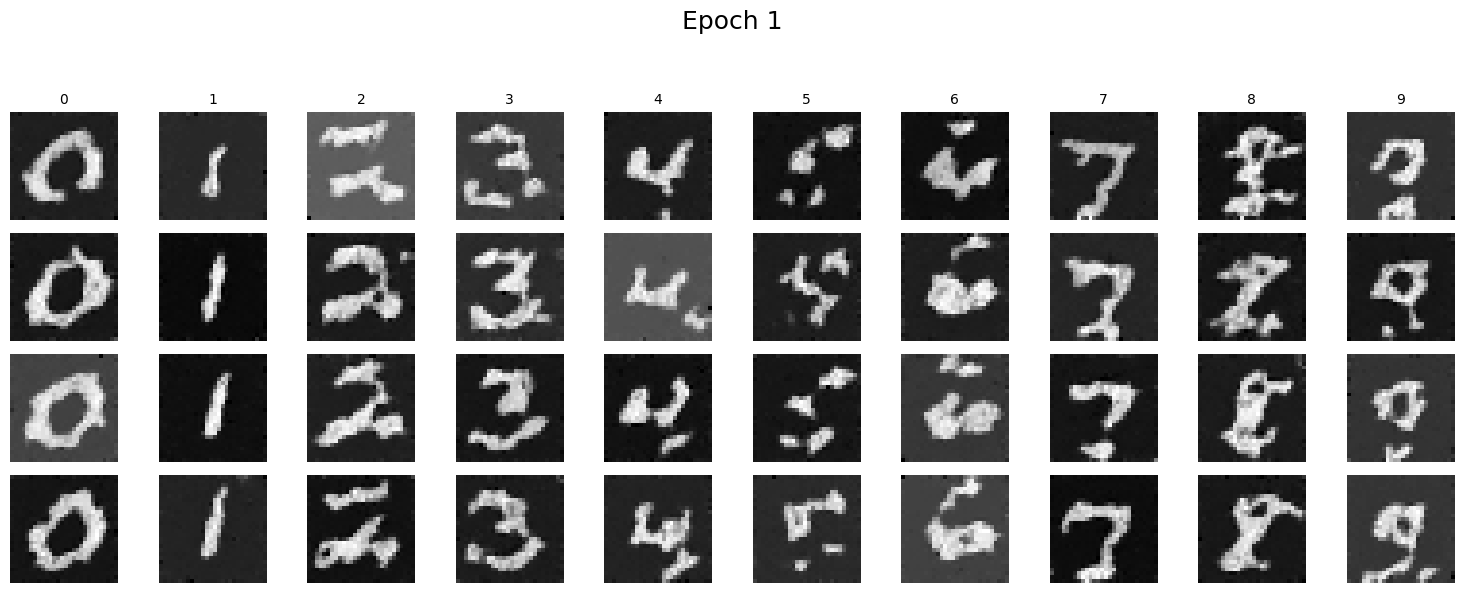

Sampling for Epoch 5 ...


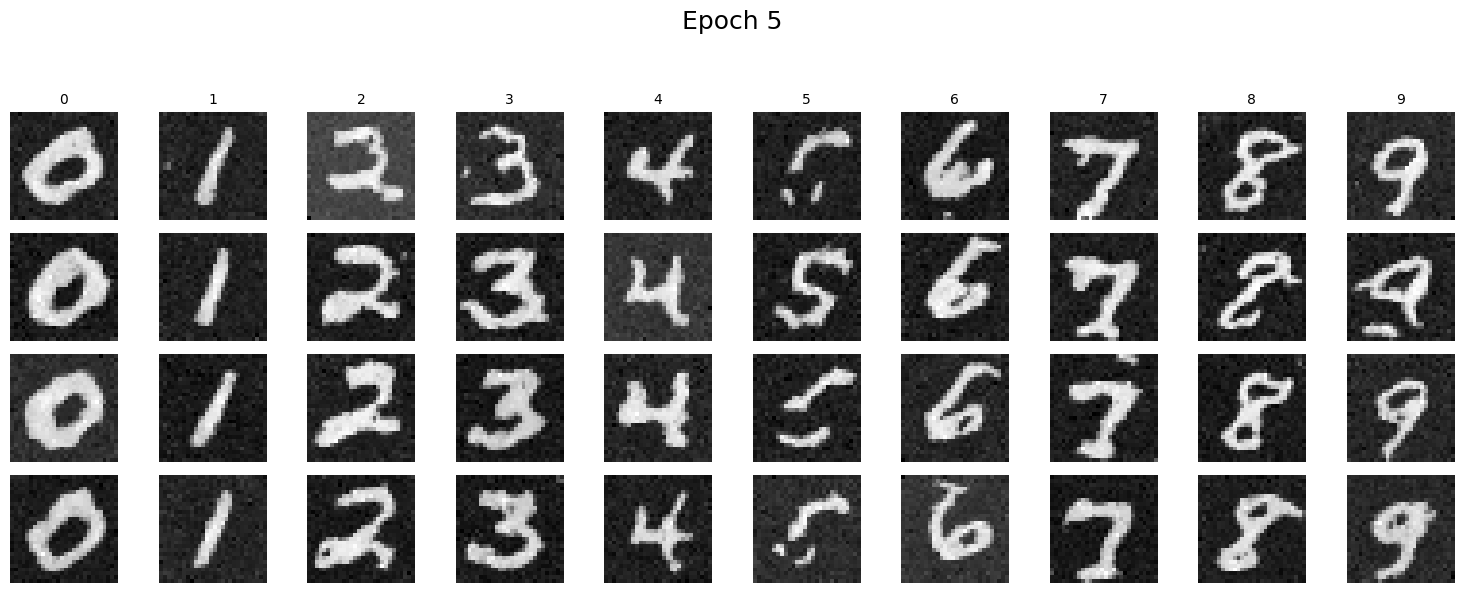

Sampling for Epoch 10 ...


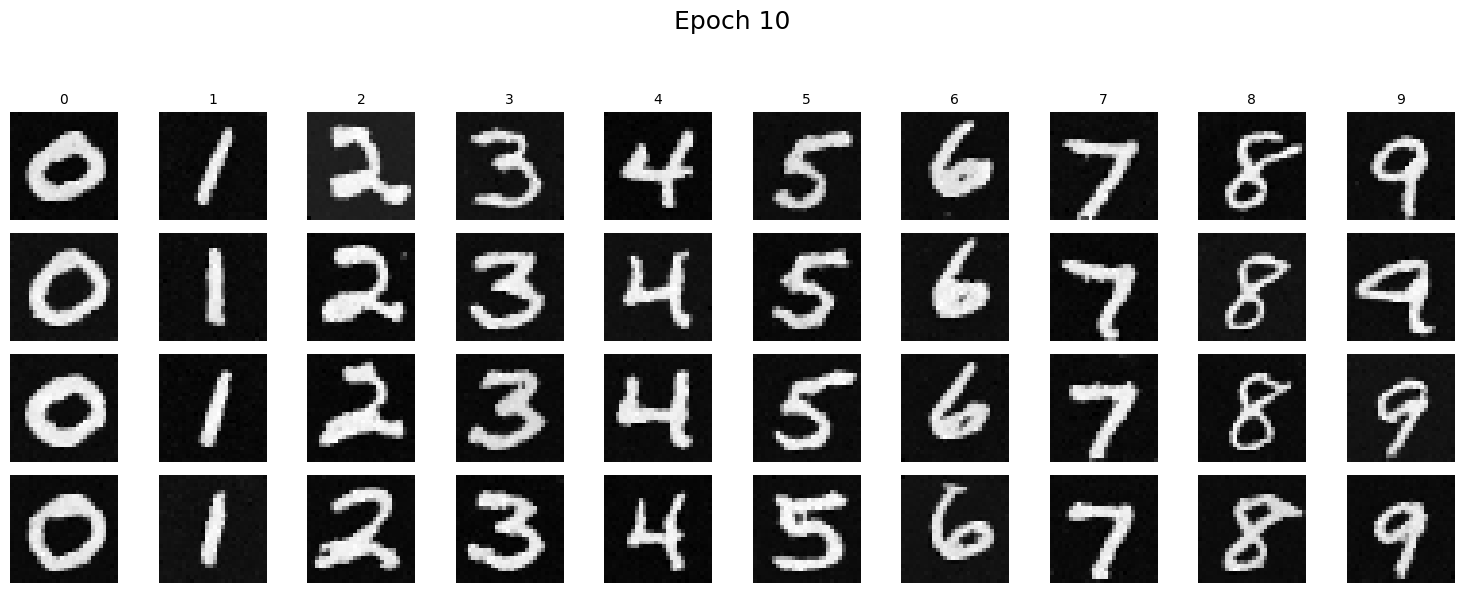

In [25]:
# Sampling from the UNet
# ===== your code here! ====
# ===== Class-Conditional Sampling Visualization =====
# 1, 5, 10 epoch → each output a grid: 4 rows × 10 classes


def load_cc_unet(ckpt_path):
    """Load UNet weights into a fresh ClassConditionalUNet."""
    model = ClassConditionalUNet(
        in_channels=1,
        num_classes=10,
        num_hiddens=64,
    ).to(device)

    # load state_dict (UNet only)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    return model


# which checkpoints to visualize
checkpoints = {
    "Epoch 1":  "cc_unet_epoch_1.pth",
    "Epoch 5":  "cc_unet_epoch_5.pth",
    "Epoch 10": "cc_unet_epoch_10.pth",
}

num_rows = 4
num_classes = 10
num_ts = 300  # should match FM wrapper

for title, ckpt_path in checkpoints.items():

    # load pure UNet
    unet = load_cc_unet(ckpt_path)

    # wrap with FM interface
    model = ClassConditionalFM(
        unet=unet,
        num_ts=300,
        p_uncond=0.1,
    ).to(device)

    print(f"Sampling for {title} ...")

    # setup figure: 4 rows × 10 columns
    fig, axs = plt.subplots(num_rows, num_classes, figsize=(num_classes*1.5, num_rows*1.5))
    fig.suptitle(title, fontsize=18)

    for row in range(num_rows):
        for cls in range(num_classes):

            c = torch.tensor([cls], device=device)
            sample, _ = model.sample(
                c=c,
                img_wh=(28, 28),
                guidance_scale=5.0,
                seed=row * num_classes + cls,   # different seed
            )

            axs[row, cls].imshow(sample[0,0].cpu(), cmap="gray")
            axs[row, cls].axis("off")

            if row == 0:
                axs[row, cls].set_title(str(cls), fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# ===== end of code ====

# Without Scheduler:

Start training...


100%|██████████| 235/235 [00:41<00:00,  5.60it/s]


[Epoch 1/10]  loss = 0.111549
Saved checkpoint: cc_unet_epoch_1.pth


100%|██████████| 235/235 [00:42<00:00,  5.56it/s]


[Epoch 2/10]  loss = 0.124555


...

[Epoch 8/10]  loss = 0.096961


100%|██████████| 235/235 [00:42<00:00,  5.49it/s]


[Epoch 9/10]  loss = 0.084627


100%|██████████| 235/235 [00:42<00:00,  5.47it/s]


[Epoch 10/10]  loss = 0.086442
Saved checkpoint: cc_unet_epoch_10.pth
Training done.


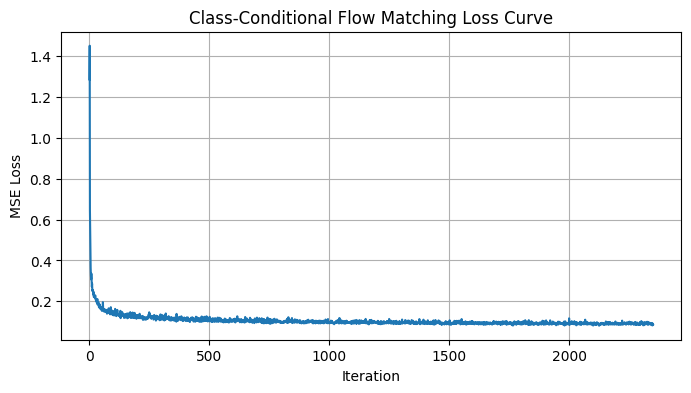

In [26]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
cc_unet = ClassConditionalUNet(
    in_channels=1,
    num_classes=10,
    num_hiddens=64,
).to(device)

model = ClassConditionalFM(
    unet=cc_unet,
    num_ts=300,
    p_uncond=0.1,
).to(device)
# ====== Training for Class-Conditional Flow Matching ======

num_epochs = 10
num_ts = 300     # already set inside model, here only for clarity
lr = 1e-2

optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)

# exponential lr scheduler
gamma = 0.1 ** (1.0 / num_epochs)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

class_flow_losses = []

print("Start training...")

for epoch in range(num_epochs):
    model.train()

    for x, c in tqdm(train_loader):
        x = x.to(device)
        c = c.to(device)

        # Algorithm 3 loss
        loss = model(x, c)

        optimizer.zero_grad()
        loss.backward()
        # prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        class_flow_losses.append(loss.item())

    # scheduler.step()

    print(f"[Epoch {epoch+1}/{num_epochs}]  loss = {loss.item():.6f}")

    # ===== 保存 checkpoint at epoch 1, 5, 10 =====
    if (epoch + 1) in [1, 5, 10]:
        torch.save(model.unet.state_dict(), f"cc_unet_epoch_{epoch+1}_no_scheduler.pth")
        print(f"Saved checkpoint: cc_unet_epoch_{epoch+1}.pth")

print("Training done.")

plt.figure(figsize=(8,4))
plt.plot(class_flow_losses)
plt.title("Class-Conditional Flow Matching Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


# ===== end of code ====

Sampling for Epoch 1 ...


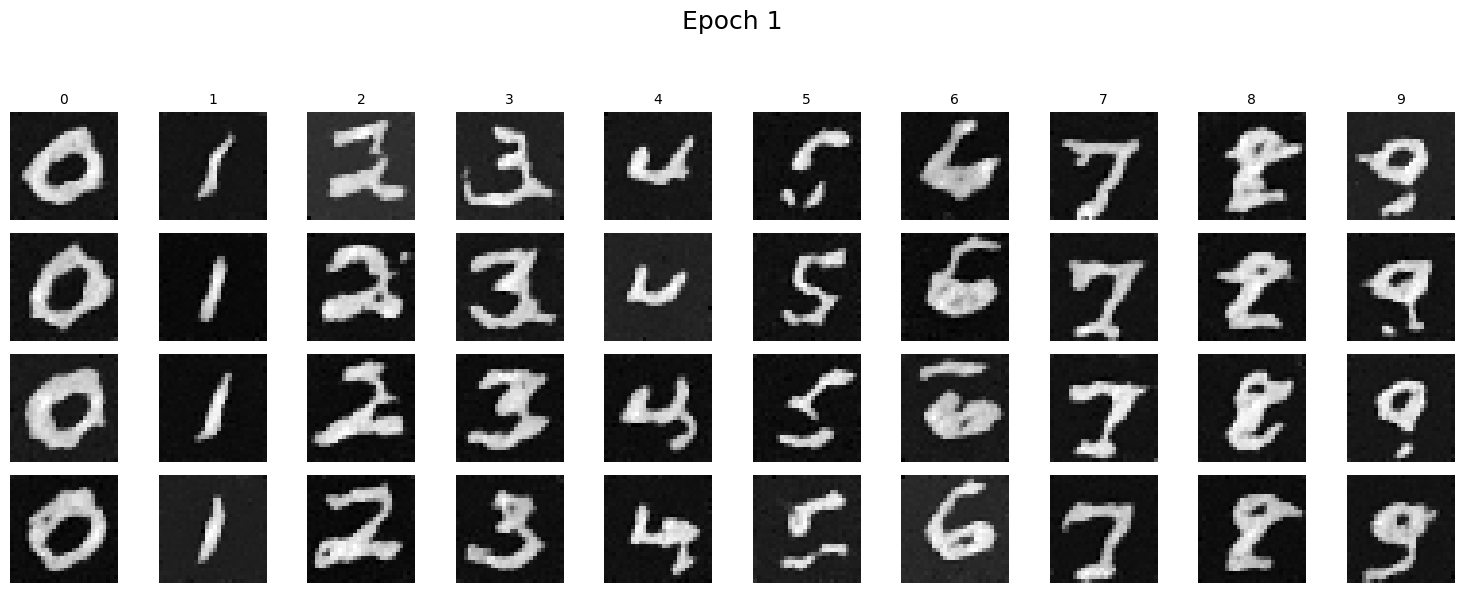

Sampling for Epoch 5 ...


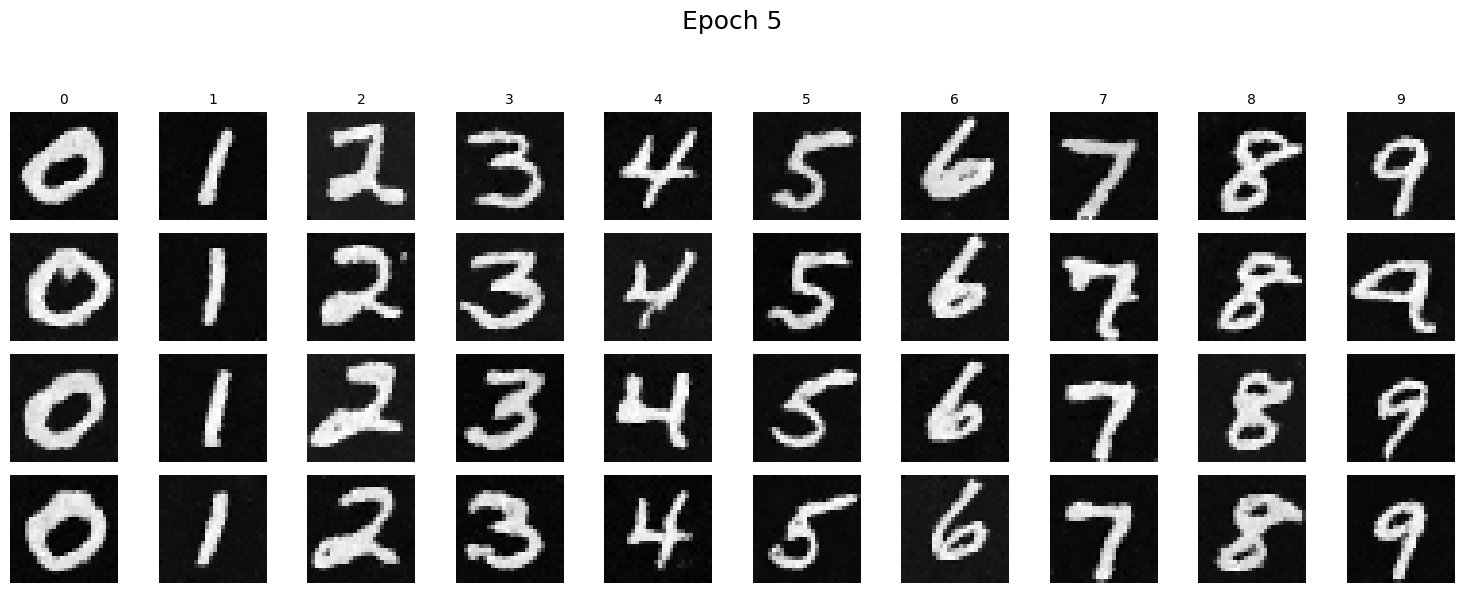

Sampling for Epoch 10 ...


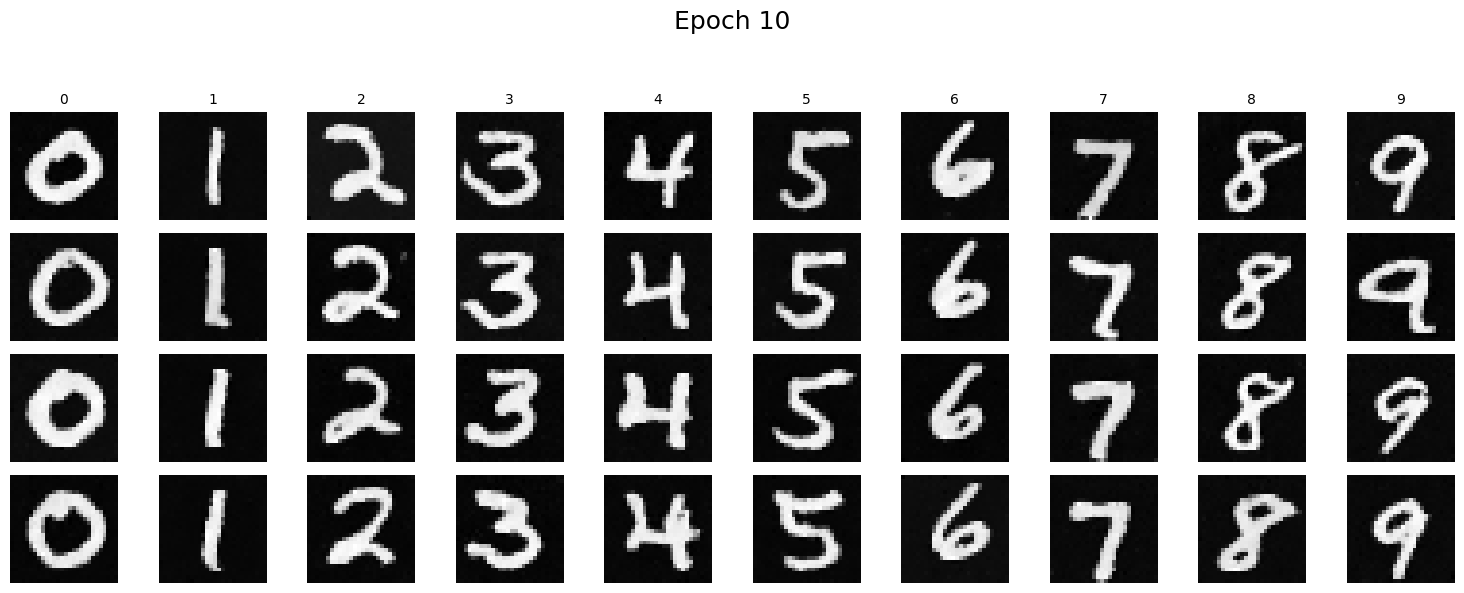

In [27]:
# Sampling from the UNet
# ===== your code here! ====
# ===== Class-Conditional Sampling Visualization =====
# 1, 5, 10 epoch → each output a grid: 4 rows × 10 classes


def load_cc_unet(ckpt_path):
    """Load UNet weights into a fresh ClassConditionalUNet."""
    model = ClassConditionalUNet(
        in_channels=1,
        num_classes=10,
        num_hiddens=64,
    ).to(device)

    # load state_dict (UNet only)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    return model


# which checkpoints to visualize
checkpoints = {
    "Epoch 1":  "cc_unet_epoch_1_no_scheduler.pth",
    "Epoch 5":  "cc_unet_epoch_5_no_scheduler.pth",
    "Epoch 10": "cc_unet_epoch_10_no_scheduler.pth",
}

num_rows = 4
num_classes = 10
num_ts = 300  # should match FM wrapper

for title, ckpt_path in checkpoints.items():

    # load pure UNet
    unet = load_cc_unet(ckpt_path)

    # wrap with FM interface
    model = ClassConditionalFM(
        unet=unet,
        num_ts=300,
        p_uncond=0.1,
    ).to(device)

    print(f"Sampling for {title} ...")

    # setup figure: 4 rows × 10 columns
    fig, axs = plt.subplots(num_rows, num_classes, figsize=(num_classes*1.5, num_rows*1.5))
    fig.suptitle(title, fontsize=18)

    for row in range(num_rows):
        for cls in range(num_classes):

            c = torch.tensor([cls], device=device)
            sample, _ = model.sample(
                c=c,
                img_wh=(28, 28),
                guidance_scale=5.0,
                seed=row * num_classes + cls,   # different seed
            )

            axs[row, cls].imshow(sample[0,0].cpu(), cmap="gray")
            axs[row, cls].axis("off")

            if row == 0:
                axs[row, cls].set_title(str(cls), fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# ===== end of code ====